# Aim of the notebook
In this notebook we will process adata and define populations

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define paths

In [4]:
path_to_write='/media/sergio/GBX/Data_for_stvelo/raw_data/DevLung/GW_15/'

In [5]:
adata=sc.read(path_to_write+'adata.h5ad')

# Define populations

In [6]:
adata

AnnData object with n_obs × n_vars = 861720 × 541
    obs: 'cell_id', 'x_centroid', 'y_centroid'
    var: 'gene_name'
    layers: 'spliced', 'unspliced'

In [8]:
adata.layers['raw']=adata.layers['spliced']+adata.layers['unspliced']

In [ ]:
# filter, normalize 
sc.pp.filter_cells(adata,min_counts = 20)
sc.pp.filter_genes(adata,min_cells = 4)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
# pca, neighbours, umap, leiden
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors = 15 , n_pcs=0)
sc.tl.umap(adata,min_dist=0.05)
sc.tl.leiden(adata,resolution = 0.5 )
sc.tl.rank_genes_groups(adata,groupby='leiden')

In [ ]:
adata.obsm['spatial']=np.array(adata.obs.loc[:,['x_centroid','y_centroid']])

In [17]:
import os 
adata.write(os.path.join(path_to_write,'adata_for_velocity_processed.h5ad'))

# Generate basic plots

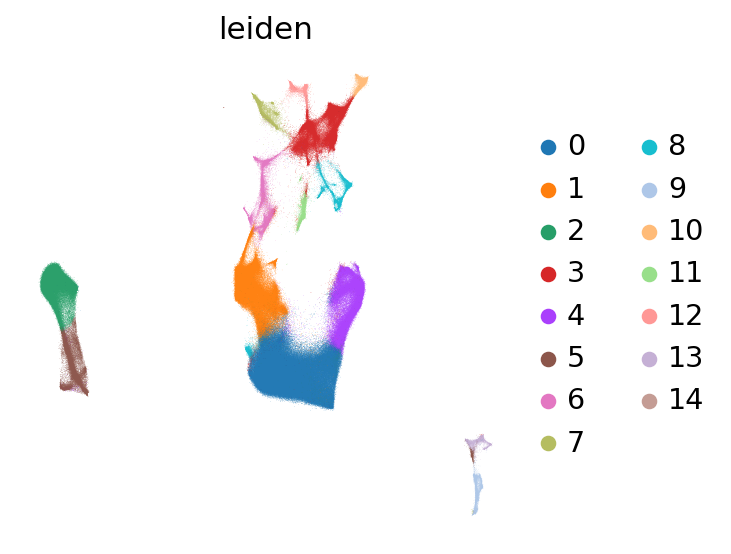

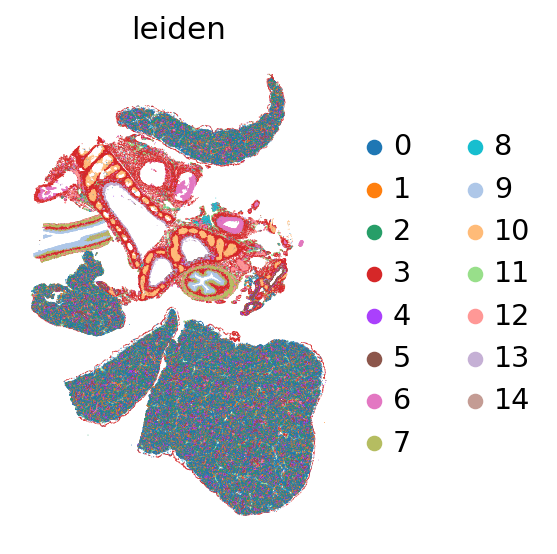

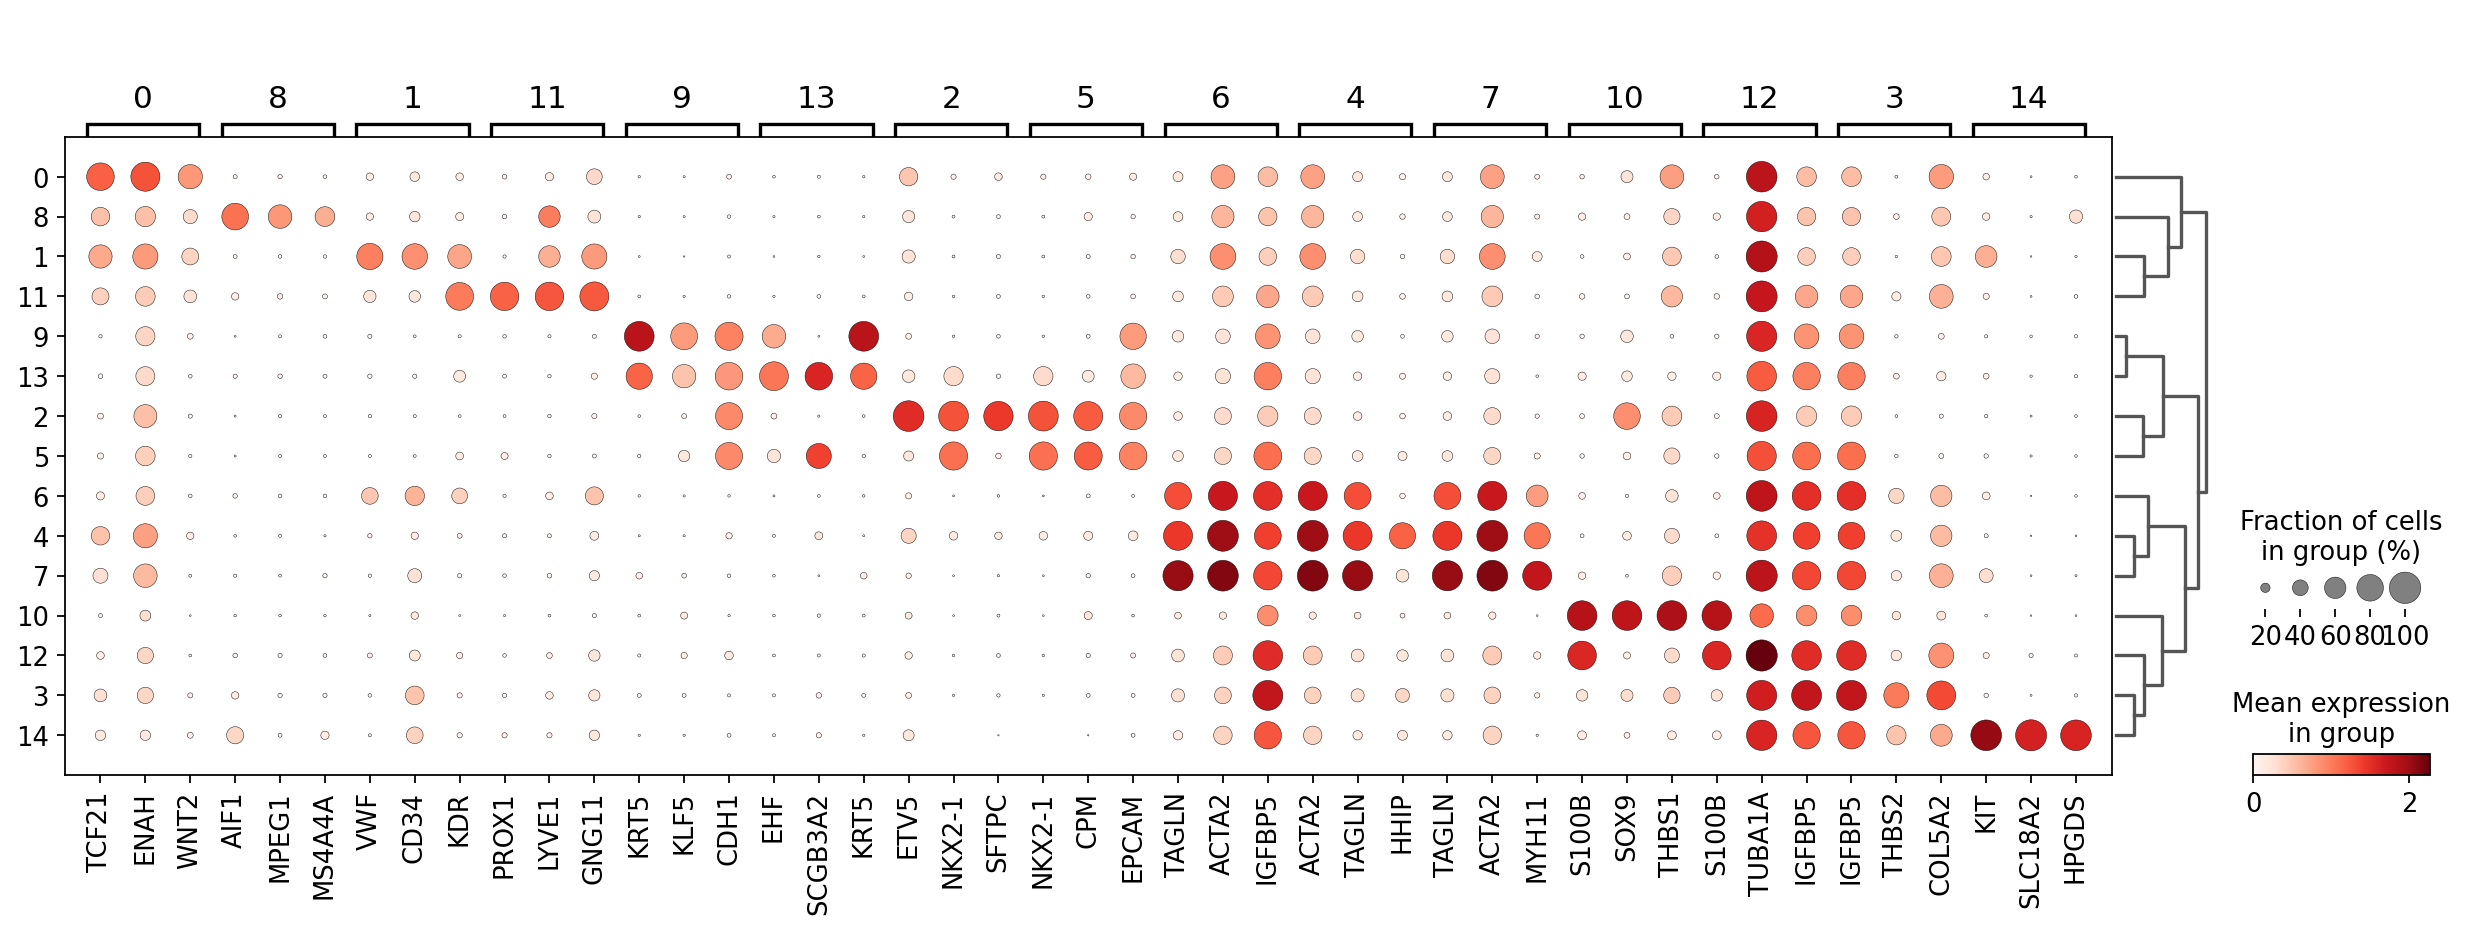

In [18]:
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=150, frameon=False, vector_friendly=True, fontsize=14, format='pdf', ipython_format='png2x')
sc.pl.umap(adata,color='leiden')
sc.pl.spatial(adata,color='leiden',spot_size=30)
sc.pl.rank_genes_groups_dotplot(adata,n_genes=3)


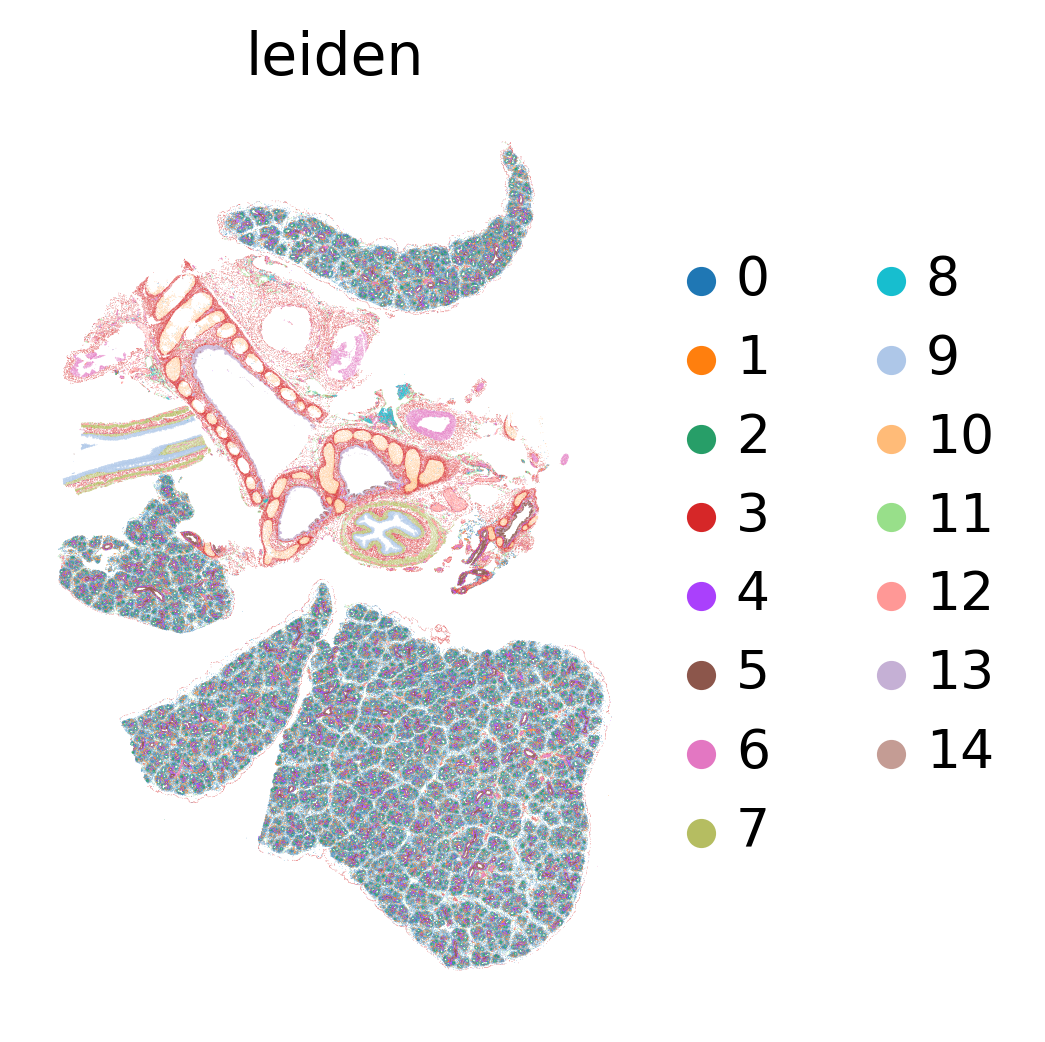

In [19]:
sc.set_figure_params(scanpy=True, dpi=150, dpi_save=150, frameon=False, vector_friendly=True, fontsize=14, format='pdf', ipython_format='png2x')

sc.pl.spatial(adata,color='leiden',spot_size=10)


In [22]:
adata.obs.to_csv(os.path.join(path_to_write,'positions.csv'))

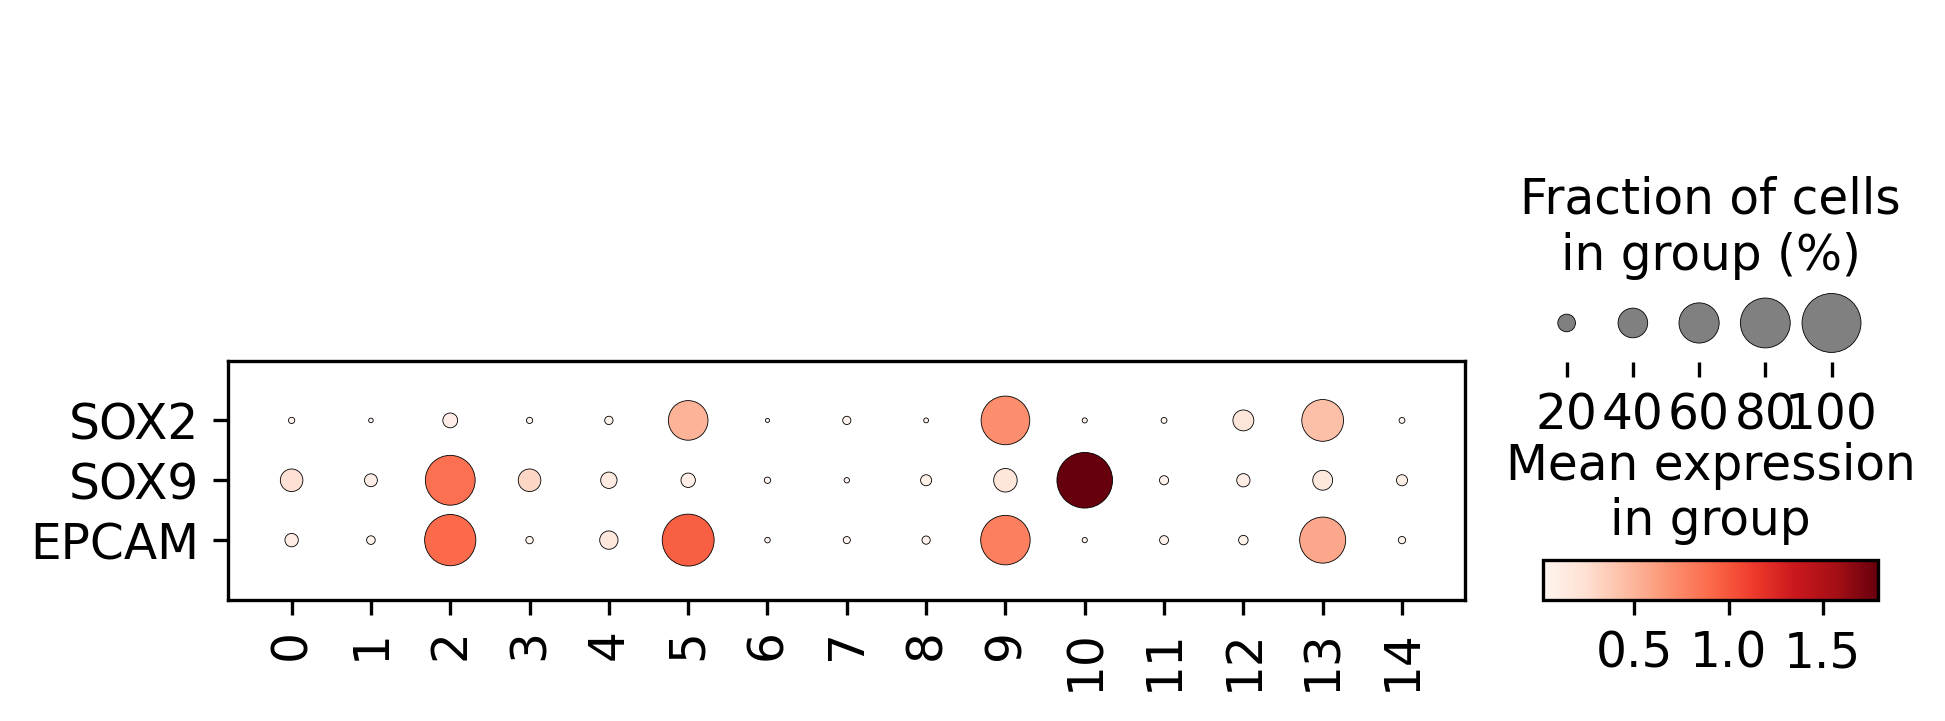

In [27]:
sc.pl.dotplot(adata,['SOX2','SOX9','EPCAM'],groupby='leiden',swap_axes=True)

In [32]:
adata

AnnData object with n_obs × n_vars = 840644 × 541
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'n_counts', 'leiden'
    var: 'gene_name', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'rank_genes_groups', 'leiden_colors', 'dendrogram_leiden'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'spliced', 'unspliced', 'raw'
    obsp: 'distances', 'connectivities'